## **Exercise 1**

In [ ]:
# load functions and data
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import seaborn as sns

df = sns.load_dataset("penguins")
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [ ]:
df.fillna(df.select_dtypes(include='number').mean().round(1), inplace=True)
# df.fillna(df.mean(),inplace=True)
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,43.9,17.2,200.9,4201.8,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,43.9,17.2,200.9,4201.8,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


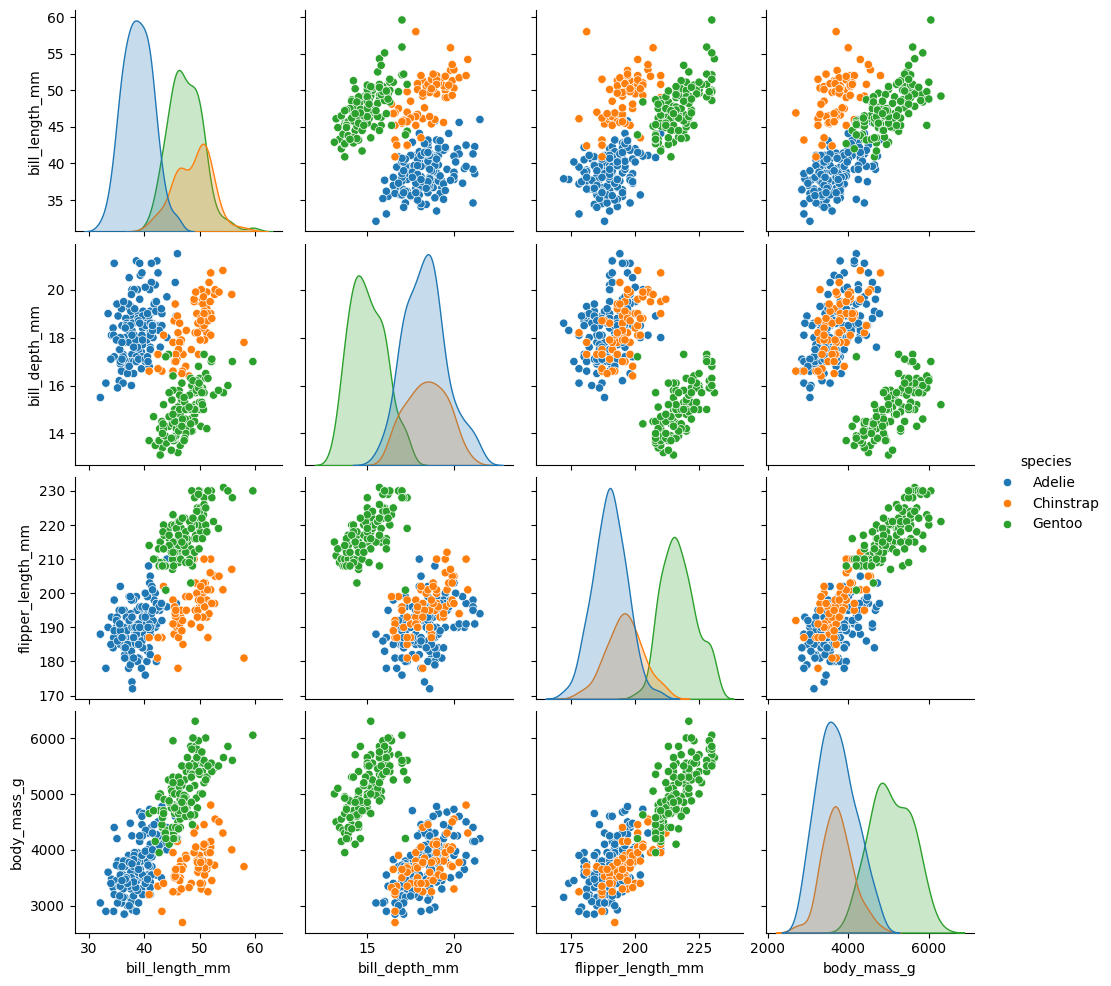

In [ ]:
# 1.a create again a pairplot with hue on species
sns.pairplot(df, hue='species')

In [ ]:
# 1.b create a correlation table by applying the .corr() method to a dataframe
df.select_dtypes(include='number').corr()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.235053,0.656181,0.595110
bill_depth_mm,-0.235053,1.000000,-0.583850,-0.471915
flipper_length_mm,0.656181,-0.583850,1.000000,0.871202
body_mass_g,0.595110,-0.471915,0.871202,1.000000


<Axes: >

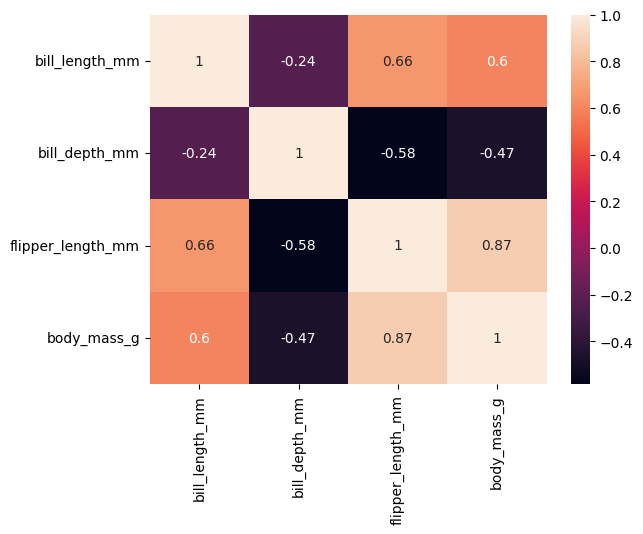

In [ ]:
# 1.c add the correlation table to seaborns heatmap function
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)

## **Exercise 2**

In [42]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt

# load data and store in variable df
df = pd.read_csv('https://drive.google.com/uc?id=1Rzq2VqPVRM2kfMuh_jToJKzKUvBOC0vp')

df.head()

,id,price,neighbourhood_group_cleansed,latitude,longitude,bathrooms,availability_30,beds,bedrooms,review_scores_value,bed_type,minimum_nights,maximum_nights,availability_365,property_type,is_business_travel_ready,cleaning_fee,room_type,square_feet,guests_included
0,28684898,$50.00,Neukölln,52.473978,13.454423,1.0,18,2.0,2.0,9.0,Real Bed,1,13,73,Apartment,f,$0.00,Private room,NaN,1
1,22607348,$10.00,Treptow - Köpenick,52.468095,13.487103,1.0,0,1.0,1.0,9.0,Real Bed,30,1124,156,Apartment,f,NaN,Private room,NaN,1
2,21019199,$35.00,Neukölln,52.481810,13.437268,1.0,0,1.0,1.0,9.0,Real Bed,1,1125,0,Apartment,f,$15.00,Private room,NaN,1
3,21919556,$99.00,Pankow,52.537269,13.416036,2.0,0,2.0,2.0,NaN,Real Bed,14,41,35,Apartment,f,$50.00,Entire home/apt,NaN,1
4,4820648,$39.00,Friedrichshain-Kreuzberg,52.491483,13.387362,1.0,0,1.0,1.0,9.0,Real Bed,60,1125,289,Apartment,f,NaN,Entire home/apt,NaN,1


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13531 entries, 0 to 13530
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            13531 non-null  int64  
 1   price                         13531 non-null  object 
 2   neighbourhood_group_cleansed  13531 non-null  object 
 3   latitude                      13531 non-null  float64
 4   longitude                     13531 non-null  float64
 5   bathrooms                     13508 non-null  float64
 6   availability_30               13531 non-null  int64  
 7   beds                          13502 non-null  float64
 8   bedrooms                      13520 non-null  float64
 9   review_scores_value           10853 non-null  float64
 10  bed_type                      13531 non-null  object 
 11  minimum_nights                13531 non-null  int64  
 12  maximum_nights                13531 non-null  int64  
 13  a

# Cleaning string from float data

In [3]:
# 2.a the price is currently stored as a string, for example: $1,000.00
# we need to remove the dollar sign and the comma, afterwars we can transform the column to type float
df['price'] =  df['price'].str.replace('$','')# replace dollar sign
df['price'] = df['price'].str.replace(',','') # replace comma
df['price'] = df['price'].astype(float) # transform to float

In [4]:
# 2.b the same can be done with the column cleaning_fee
df['cleaning_fee'] = df['cleaning_fee'].str.replace('$','')
df['cleaning_fee'] = df['cleaning_fee'].str.replace(',','')
df['cleaning_fee'] = df['cleaning_fee'].astype(float)

In [5]:
# Make 'PRICE' already with float data

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13531 entries, 0 to 13530
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            13531 non-null  int64  
 1   price                         13531 non-null  float64
 2   neighbourhood_group_cleansed  13531 non-null  object 
 3   latitude                      13531 non-null  float64
 4   longitude                     13531 non-null  float64
 5   bathrooms                     13508 non-null  float64
 6   availability_30               13531 non-null  int64  
 7   beds                          13502 non-null  float64
 8   bedrooms                      13520 non-null  float64
 9   review_scores_value           10853 non-null  float64
 10  bed_type                      13531 non-null  object 
 11  minimum_nights                13531 non-null  int64  
 12  maximum_nights                13531 non-null  int64  
 13  a

In [40]:
df['room_type'].value_counts()

#Need to encoding this type (PRE-PROCESSING SESSION)

,count
room_type,
Private room,6876
Entire home/apt,6481
Shared room,174


In [41]:
df.groupby('room_type')['price'].mean()

,price
room_type,
Entire home/apt,84.815152
Private room,56.291012
Shared room,66.344828


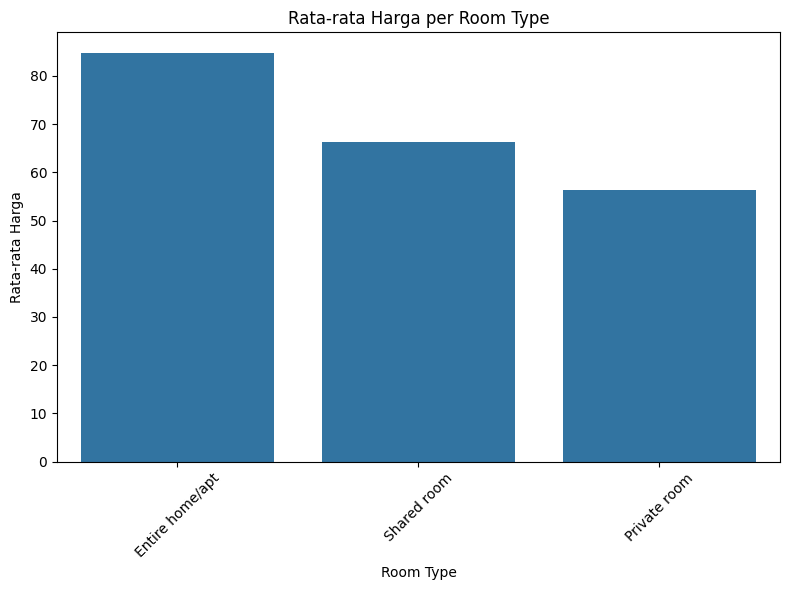

In [39]:
# Check correlation between room_type and price
avg_price_per_room = df.groupby('room_type')['price'].mean().sort_values(ascending=False)

# Make bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x=avg_price_per_room.index, y=avg_price_per_room.values)
plt.title('Rata-rata Harga per Room Type')
plt.xlabel('Room Type')
plt.ylabel('Rata-rata Harga')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Check missing values (nilai yang kosong)

In [6]:
# 2.c some columns have a lot of missing values.
# try to understand how the following comand works.
# try to execute df.isna() only, then df.isna().sum() ...

df.isna().sum().sort_values(ascending=False)
# df.isna().sort_values(ascending=False)

,0
square_feet,13260
cleaning_fee,4272
review_scores_value,2678
beds,29
bathrooms,23
bedrooms,11
price,0
id,0
latitude,0
neighbourhood_group_cleansed,0


In [7]:
# 2.d fill ne missing values with the mean value, check with the above command that
# no missing values are left
df = df.fillna(df.select_dtypes('number').mean())
df.isna().sum().sort_values(ascending=False)

,0
id,0
price,0
neighbourhood_group_cleansed,0
latitude,0
longitude,0
bathrooms,0
availability_30,0
beds,0
bedrooms,0
review_scores_value,0


# Check CORRELATIONS for each columns, expecially for PRICE

In [8]:
# 2.d compute the corelations and look which features have a high corelation with price
# df.corr().style.background_gradient()
df.select_dtypes(include='number').corr().style.background_gradient()

,id,price,latitude,longitude,bathrooms,availability_30,beds,bedrooms,review_scores_value,minimum_nights,maximum_nights,availability_365,cleaning_fee,square_feet,guests_included
id,1.000000,0.036903,0.000890,-0.021492,-0.009163,0.124149,-0.054175,-0.078555,0.034258,-0.039821,-0.007156,-0.063357,-0.081665,-0.002346,-0.073048
price,0.036903,1.000000,-0.000523,-0.043415,0.056410,0.113626,0.093743,0.105298,-0.030973,0.006582,-0.000835,0.103613,0.243949,0.011013,0.093485
latitude,0.000890,-0.000523,1.000000,-0.103196,0.002291,-0.007762,0.015873,0.010359,-0.007964,0.012127,0.008208,0.004840,0.028375,-0.010605,0.030783
longitude,-0.021492,-0.043415,-0.103196,1.000000,0.000848,-0.052582,-0.005210,0.008254,0.017827,-0.024320,-0.004821,-0.082404,-0.045074,0.000221,-0.001144
bathrooms,-0.009163,0.056410,0.002291,0.000848,1.000000,0.036989,0.267756,0.300103,-0.003459,-0.004560,-0.003453,0.039848,0.110863,0.041437,0.159584
availability_30,0.124149,0.113626,-0.007762,-0.052582,0.036989,1.000000,0.128834,0.040929,-0.054270,0.032532,0.012623,0.541278,0.074724,0.001048,0.082160
beds,-0.054175,0.093743,0.015873,-0.005210,0.267756,0.128834,1.000000,0.615204,-0.089233,0.010716,-0.006461,0.191947,0.219194,0.077113,0.445370
bedrooms,-0.078555,0.105298,0.010359,0.008254,0.300103,0.040929,0.615204,1.000000,-0.021724,0.000833,-0.002958,0.075513,0.211437,0.076173,0.372031
review_scores_value,0.034258,-0.030973,-0.007964,0.017827,-0.003459,-0.054270,-0.089233,-0.021724,1.000000,-0.013551,-0.006510,-0.090955,-0.090198,-0.007284,-0.062850
minimum_nights,-0.039821,0.006582,0.012127,-0.024320,-0.004560,0.032532,0.010716,0.000833,-0.013551,1.000000,-0.001543,0.088981,0.084426,-0.005234,0.012834


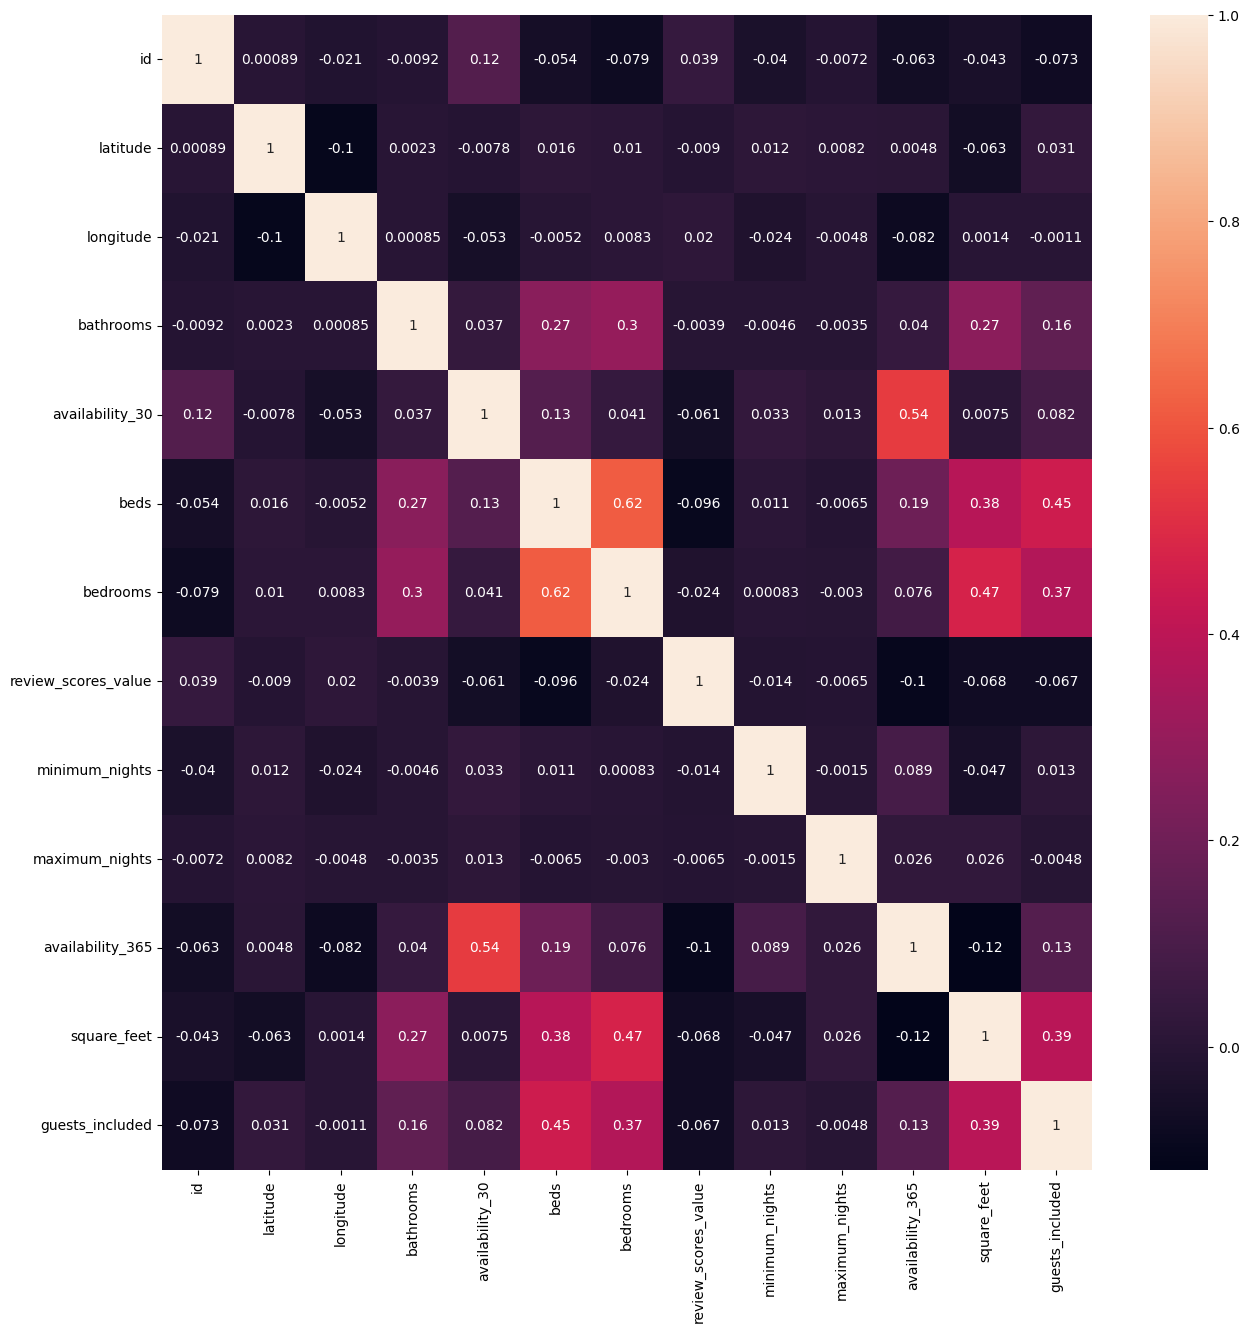

In [43]:
import seaborn as sns

corr_matrix = df.select_dtypes('number').corr()
plt.figure(figsize=(15,15))
sns.heatmap(corr_matrix, annot=True)
plt.show()


In [33]:
# Features correlations with 'price'
korelasi_price = df.select_dtypes('number').corr()['price'].sort_values(ascending=False)

# Tampilkan hasil
print(korelasi_price)

price                  1.000000
cleaning_fee           0.243949
availability_30        0.113626
bedrooms               0.105298
availability_365       0.103613
beds                   0.093743
guests_included        0.093485
bathrooms              0.056410
id                     0.036903
square_feet            0.011013
minimum_nights         0.006582
latitude              -0.000523
maximum_nights        -0.000835
review_scores_value   -0.030973
longitude             -0.043415
Name: price, dtype: float64


# Check OUTLIER using BOXPLOT

In [27]:
outlier_summary = {}

# Ambil kolom numerik saja
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter outlier
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    # Simpan hasil
    outlier_summary[col] = {
        'jumlah_outlier': outliers.shape[0],
        # 'nilai_outlier': outliers[col].tolist()
    }

# Tampilkan sebagai DataFrame
outlier_df = pd.DataFrame.from_dict(outlier_summary, orient='index')
print(outlier_df)

                     jumlah_outlier
id                                0
price                           770
latitude                        159
longitude                       440
bathrooms                      1667
availability_30                1996
beds                            877
bedrooms                       3240
review_scores_value             249
minimum_nights                 1480
maximum_nights                    9
availability_365               1036
cleaning_fee                    795
square_feet                     271
guests_included                3059


In [28]:
df.describe()

,id,price,latitude,longitude,bathrooms,availability_30,beds,bedrooms,review_scores_value,minimum_nights,maximum_nights,availability_365,cleaning_fee,square_feet,guests_included
count,1.353100e+04,13531.000000,13531.000000,13531.000000,13531.000000,13531.000000,13531.000000,13531.000000,13531.000000,13531.000000,1.353100e+04,13531.000000,13531.000000,13531.000000,13531.000000
mean,1.573089e+07,70.082625,52.509956,13.405871,1.095203,4.976498,1.627092,1.158728,9.408458,7.187421,1.484241e+05,80.442687,26.871368,480.416974,1.334122
std,8.580394e+06,255.451132,0.030773,0.058517,0.335184,8.692006,1.179820,0.652097,0.763172,47.773700,1.215720e+07,119.588978,27.292448,73.411566,0.839897
min,2.695000e+03,0.000000,52.346203,13.103557,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,1.000000e+00,0.000000,0.000000,0.000000,1.000000
25%,8.041528e+06,30.000000,52.489082,13.374950,1.000000,0.000000,1.000000,1.000000,9.000000,2.000000,2.000000e+01,0.000000,15.000000,480.416974,1.000000
50%,1.697254e+07,45.000000,52.509229,13.416764,1.000000,0.000000,1.000000,1.000000,9.408458,2.000000,1.124000e+03,4.000000,26.871368,480.416974,1.000000
75%,2.264464e+07,70.000000,52.532808,13.439258,1.000000,6.000000,2.000000,1.000000,10.000000,4.000000,1.125000e+03,130.000000,30.000000,480.416974,1.000000
max,2.986735e+07,9000.000000,52.651670,13.721671,8.500000,30.000000,22.000000,12.000000,10.000000,5000.000000,1.000000e+09,365.000000,2000.000000,4639.000000,16.000000


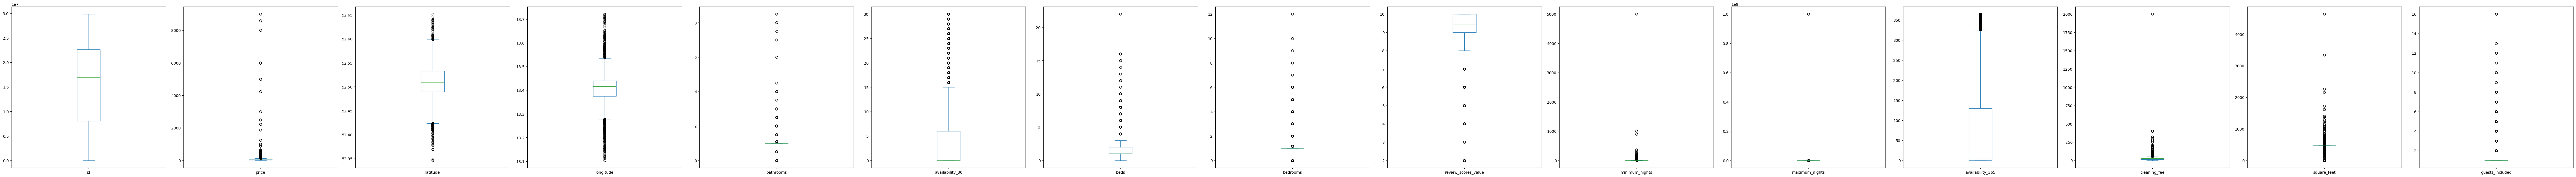

In [25]:
df.select_dtypes('number').plot(kind='box', subplots=True, layout=(16, 16), figsize=(100, 100), sharex=False, sharey=False)
plt.tight_layout()
plt.show()

# Pre-Processing

In [ ]:
# Label Encoder for some columns (room_type)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['room_type_encoded'] = le.fit_transform(df['room_type'])

# Modelling

In [9]:
# load functions
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

In [10]:
# 2.e define a feature dataframe with 3 features and the target column price
# create a train and test dataset
X = df[['square_feet','cleaning_fee', 'latitude','longitude','bedrooms','review_scores_value','minimum_nights']]
y_target = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y_target, test_size=0.3)

In [11]:
# 2.f train a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

model.predict(X_train)

array([55.16696999, 93.27106399, 61.59042278, ..., 55.50618479,
       56.95116939, 79.3195516 ])

In [12]:
# 2.g test your model
y_predict = model.predict(X_test)
mse = mean_squared_error(y_test, y_predict)
rmse = np.sqrt(mse)
print(rmse)   # Model evaluation

262.63354051400063


In [30]:
# Print result of predict
hasil_prediksi = X_test.copy()
hasil_prediksi['harga_asli'] = y_test.values
hasil_prediksi['harga_prediksi'] = y_predict

# Show the first 5 row
print(hasil_prediksi.head())

       square_feet  cleaning_fee   latitude  longitude  bedrooms  \
9342    480.416974     25.000000  52.418665  13.200735       1.0   
7688    480.416974     50.000000  52.551406  13.381206       1.0   
415     480.416974     26.871368  52.543217  13.416700       1.0   
11616   480.416974     20.000000  52.544962  13.423479       1.0   
540     480.416974     30.000000  52.529430  13.399956       1.0   

       review_scores_value  minimum_nights  harga_asli  harga_prediksi  
9342             10.000000               4        24.0       97.007369  
7688              9.408458              90        45.0       75.202093  
415               9.408458               1        99.0       59.977824  
11616            10.000000               1        50.0       53.963981  
540               9.000000               5        69.0       65.883844  


In [ ]:
# 2.h include more features to your model and look how the root mean square error gets lower

# NEXT WEEK